# Deep Dive into Deep Learning Optimizers
### A Comprehensive Empirical & Theoretical Benchmark: SGD, Momentum, AdaGrad, RMSProp, Adam & Nadam

**Authors (Group of 3):**
* **Person 1:** Foundations of Optimization, Standard SGD & SGD with Momentum
* **Person 2:** The Adaptive Revolution: AdaGrad & RMSProp
* **Person 3:** Modern Hybrids: Adam, Nadam & The Generalization Mystery
* **Collaborative:** Empirical Benchmark, Learning-Rate Sensitivity & Viva Defense

---

### Notebook Structure
1. **The Foundations:** Loss Landscape, Gradients, Step Size & Parameter Updates
2. **Optimizer Mechanics & Math:** 12-Point Analysis for all 6 Optimizers
3. **Reproducible Experiment Setup:** Fashion-MNIST (1,000 Sample Benchmark)
4. **Benchmark Execution:** Training all 6 Optimizers under Identical Conditions
5. **Empirical Visualizations:** Training Loss, Validation Loss, Accuracy & Peak Acc
6. **Learning-Rate Sensitivity Test:** Analyzing Stability across 4 Decades ($10^{-1}$ to $10^{-4}$)
7. **The Generalization Mystery:** Why Fast Optimization $\neq$ Best Model Quality
8. **Viva & Oral Defense Cheat Sheet:** 4-Tier Answers to Real-World Questions


## 1. The Foundational Theory

### 1.1 What is Training a Neural Network?
A neural network has millions of adjustable parameters (weights and biases $\theta$).
When we feed an input $x$, it generates a prediction $\hat{y}$, and we compute the error using a **Loss Function $L(\theta)$**.
The goal of optimization is to find the optimal parameter values $\theta^*$ that minimize $L(\theta)$.

### 1.2 The Gradient $\nabla_\theta L(\theta)$
The gradient is a vector containing all first-order partial derivatives of the loss function:
$$\nabla_\theta L(\theta) = \left[ \frac{\partial L}{\partial \theta_1}, \frac{\partial L}{\partial \theta_2}, \dots, \frac{\partial L}{\partial \theta_d} \right]^T$$
* **Direction:** The gradient always points in the direction of **steepest uphill increase**.
* **Descent Principle:** To minimize the loss, we take steps in the **exact opposite direction**: $-\nabla_\theta L(\theta)$.

### 1.3 The Baseline Parameter Update Rule
Every gradient-based optimization algorithm builds on this core formula:
$$\theta_{t+1} = \theta_t - \eta \cdot g_t$$
where:
* $\theta_t$: Current weights at time step $t$.
* $\eta$: The learning rate (step size hyperparameter).
* $g_t$: The gradient $\nabla_\theta L(\theta_t)$ at step $t$.


## 2. Summary Comparison of the 6 Optimizers

| Optimizer | 1st Moment (Direction) | 2nd Moment (Adaptive Scale) | Update Equation | Analogy |
| :--- | :---: | :---: | :--- | :--- |
| **SGD** | None | None | $\theta_{t+1} = \theta_t - \eta g_t$ | Blind hiker taking quick, noisy steps |
| **SGD + Momentum** | Exponential Average ($\gamma=0.9$) | None | $v_{t+1} = \gamma v_t + \eta g_t$<br>$\theta_{t+1} = \theta_t - v_{t+1}$ | Heavy bowling ball rolling down a valley |
| **AdaGrad** | None | Cumulative Sum ($G_t = \sum g^2$) | $\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{G_t + \epsilon}} g_t$ | An elephant remembering every past mistake |
| **RMSProp** | None | Leaky Average ($\beta=0.9$) | $v_t = \beta v_{t-1} + (1-\beta)g_t^2$<br>$\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{v_t + \epsilon}} g_t$ | Practical human focusing on recent performance |
| **Adam** | Leaky Average ($\beta_1=0.9$) | Leaky Average ($\beta_2=0.999$) | $\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \hat{m}_t$ | High-speed vehicle with active suspension |
| **Nadam** | Nesterov Lookahead | Leaky Average ($\beta_2=0.999$) | $\theta_{t+1} = \theta_t - \frac{\eta}{\sqrt{\hat{v}_t} + \epsilon} \bar{m}_t$ | Racecar driver braking before entering a curve |


In [1]:
# -------------------------------------------------------------
# STEP 1: Libraries, Device Configuration & Global Reproducibility
# -------------------------------------------------------------
import os
import copy
import random
import time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms

# Set fixed random seed for 100% scientific reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_seed(42)

# Select CPU or GPU (experiments are optimized for standard CPU execution)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[OK] Computing Device: {device}")


[OK] Computing Device: cpu


In [2]:
# -------------------------------------------------------------
# STEP 2: Dataset Loading (Fashion-MNIST with 1,000 Samples)
# -------------------------------------------------------------
# Using exactly 1,000 samples ensures lightning-fast execution (< 10 seconds per optimizer)
# while retaining 100 images per clothing category for real learning dynamics.

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.2860,), (0.3530,))
])

train_full = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
test_full = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

# Slice 1,000 training images and 1,000 validation images
train_subset = Subset(train_full, list(range(1000)))
val_subset = Subset(test_full, list(range(1000)))

train_loader = DataLoader(train_subset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_subset, batch_size=128, shuffle=False)

print(f"[OK] Loaded {len(train_subset)} training images and {len(val_subset)} validation images.")


[OK] Loaded 1000 training images and 1000 validation images.


In [3]:
# -------------------------------------------------------------
# STEP 3: Neural Network Architecture & Strict Weight Cloning
# -------------------------------------------------------------
# 3-layer MLP: 784 -> 128 -> 64 -> 10 with ReLU non-linearities.
# We clone the initial weights so every optimizer starts from the EXACT same point theta_0!

class BenchmarkMLP(nn.Module):
    def __init__(self):
        super(BenchmarkMLP, self).__init__()
        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 128),
            nn.ReLU(),
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Linear(64, 10)
        )

    def forward(self, x):
        return self.network(x)

# Create reference model and freeze initial parameter snapshot
reference_model = BenchmarkMLP().to(device)
initial_weights = copy.deepcopy(reference_model.state_dict())
criterion = nn.CrossEntropyLoss()

print("[OK] BenchmarkMLP defined. Initial weights cloned for 100% fair comparison.")


[OK] BenchmarkMLP defined. Initial weights cloned for 100% fair comparison.


In [4]:
# -------------------------------------------------------------
# STEP 4: Evaluation Metric Functions & Training Loop
# -------------------------------------------------------------
def evaluate_model(model, data_loader):
    model.eval()
    total_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for x, y in data_loader:
            x, y = x.to(device), y.to(device)
            out = model(x)
            loss = criterion(out, y)
            total_loss += loss.item() * x.size(0)
            pred = out.argmax(dim=1)
            correct += (pred == y).sum().item()
            total += x.size(0)
    return total_loss / total, (correct / total) * 100.0


def train_single_optimizer(opt_name, get_opt_fn, epochs=10):
    print(f"\n>>> Training: {opt_name} <<<")
    # Reset model to exact identical weights theta_0
    model = BenchmarkMLP().to(device)
    model.load_state_dict(copy.deepcopy(initial_weights))
    optimizer = get_opt_fn(model)
    
    history = {"train_loss": [], "val_loss": [], "val_acc": []}
    start_time = time.time()
    
    for epoch in range(1, epochs + 1):
        model.train()
        running_loss = 0.0
        total = 0
        for x, y in train_loader:
            x, y = x.to(device), y.to(device)
            optimizer.zero_grad()
            out = model(x)
            loss = criterion(out, y)
            loss.backward()
            optimizer.step()
            running_loss += loss.item() * x.size(0)
            total += x.size(0)
            
        epoch_loss = running_loss / total
        v_loss, v_acc = evaluate_model(model, val_loader)
        history["train_loss"].append(epoch_loss)
        history["val_loss"].append(v_loss)
        history["val_acc"].append(v_acc)
        print(f"  Epoch [{epoch:02d}/{epochs:02d}] | Train Loss: {epoch_loss:.4f} | Val Loss: {v_loss:.4f} | Val Acc: {v_acc:.2f}%")
        
    duration = time.time() - start_time
    print(f"[Done] {opt_name} completed in {duration:.2f}s")
    return history, duration


In [5]:
# -------------------------------------------------------------
# STEP 5: Run Benchmark on all 6 Optimizers
# -------------------------------------------------------------
optimizer_dict = {
    "SGD": lambda m: optim.SGD(m.parameters(), lr=0.05),
    "SGD + Momentum": lambda m: optim.SGD(m.parameters(), lr=0.02, momentum=0.9),
    "AdaGrad": lambda m: optim.Adagrad(m.parameters(), lr=0.01),
    "RMSProp": lambda m: optim.RMSprop(m.parameters(), lr=0.001, alpha=0.9),
    "Adam": lambda m: optim.Adam(m.parameters(), lr=0.001, betas=(0.9, 0.999)),
    "Nadam": lambda m: optim.NAdam(m.parameters(), lr=0.001, betas=(0.9, 0.999))
}

all_histories = {}
summary_rows = []
TOTAL_EPOCHS = 10

for name, fn in optimizer_dict.items():
    hist, dur = train_single_optimizer(name, fn, epochs=TOTAL_EPOCHS)
    all_histories[name] = hist
    crossed_80 = [i + 1 for i, acc in enumerate(hist["val_acc"]) if acc >= 80.0]
    speed = f"Epoch {crossed_80[0]}" if crossed_80 else "Did not cross 80%"
    
    summary_rows.append({
        "Optimizer": name,
        "Final Train Loss": round(hist["train_loss"][-1], 4),
        "Final Val Loss": round(hist["val_loss"][-1], 4),
        "Final Val Acc (%)": round(hist["val_acc"][-1], 2),
        "Peak Val Acc (%)": round(max(hist["val_acc"]), 2),
        "Epoch to 80% Acc": speed,
        "Total Time (s)": round(dur, 2)
    })

df_summary = pd.DataFrame(summary_rows)
print("\n" + "="*85)
print("FINAL 1,000-SAMPLE BENCHMARK COMPARISON TABLE")
print("="*85)
print(df_summary.to_string(index=False))



>>> Training: SGD <<<
  Epoch [01/10] | Train Loss: 2.1270 | Val Loss: 1.8502 | Val Acc: 47.50%
  Epoch [02/10] | Train Loss: 1.5197 | Val Loss: 1.2593 | Val Acc: 60.20%
  Epoch [03/10] | Train Loss: 1.0533 | Val Loss: 0.9838 | Val Acc: 66.50%
  Epoch [04/10] | Train Loss: 0.8772 | Val Loss: 0.8460 | Val Acc: 69.80%
  Epoch [05/10] | Train Loss: 0.7575 | Val Loss: 0.7914 | Val Acc: 72.00%
  Epoch [06/10] | Train Loss: 0.6979 | Val Loss: 0.7760 | Val Acc: 72.80%
  Epoch [07/10] | Train Loss: 0.6518 | Val Loss: 0.7120 | Val Acc: 73.90%
  Epoch [08/10] | Train Loss: 0.5733 | Val Loss: 0.6972 | Val Acc: 73.30%
  Epoch [09/10] | Train Loss: 0.5468 | Val Loss: 0.6652 | Val Acc: 75.90%
  Epoch [10/10] | Train Loss: 0.5142 | Val Loss: 0.6549 | Val Acc: 75.10%
[Done] SGD completed in 9.76s

>>> Training: SGD + Momentum <<<
  Epoch [01/10] | Train Loss: 2.0480 | Val Loss: 1.4596 | Val Acc: 51.80%
  Epoch [02/10] | Train Loss: 1.0337 | Val Loss: 0.8941 | Val Acc: 66.10%
  Epoch [03/10] | Train L

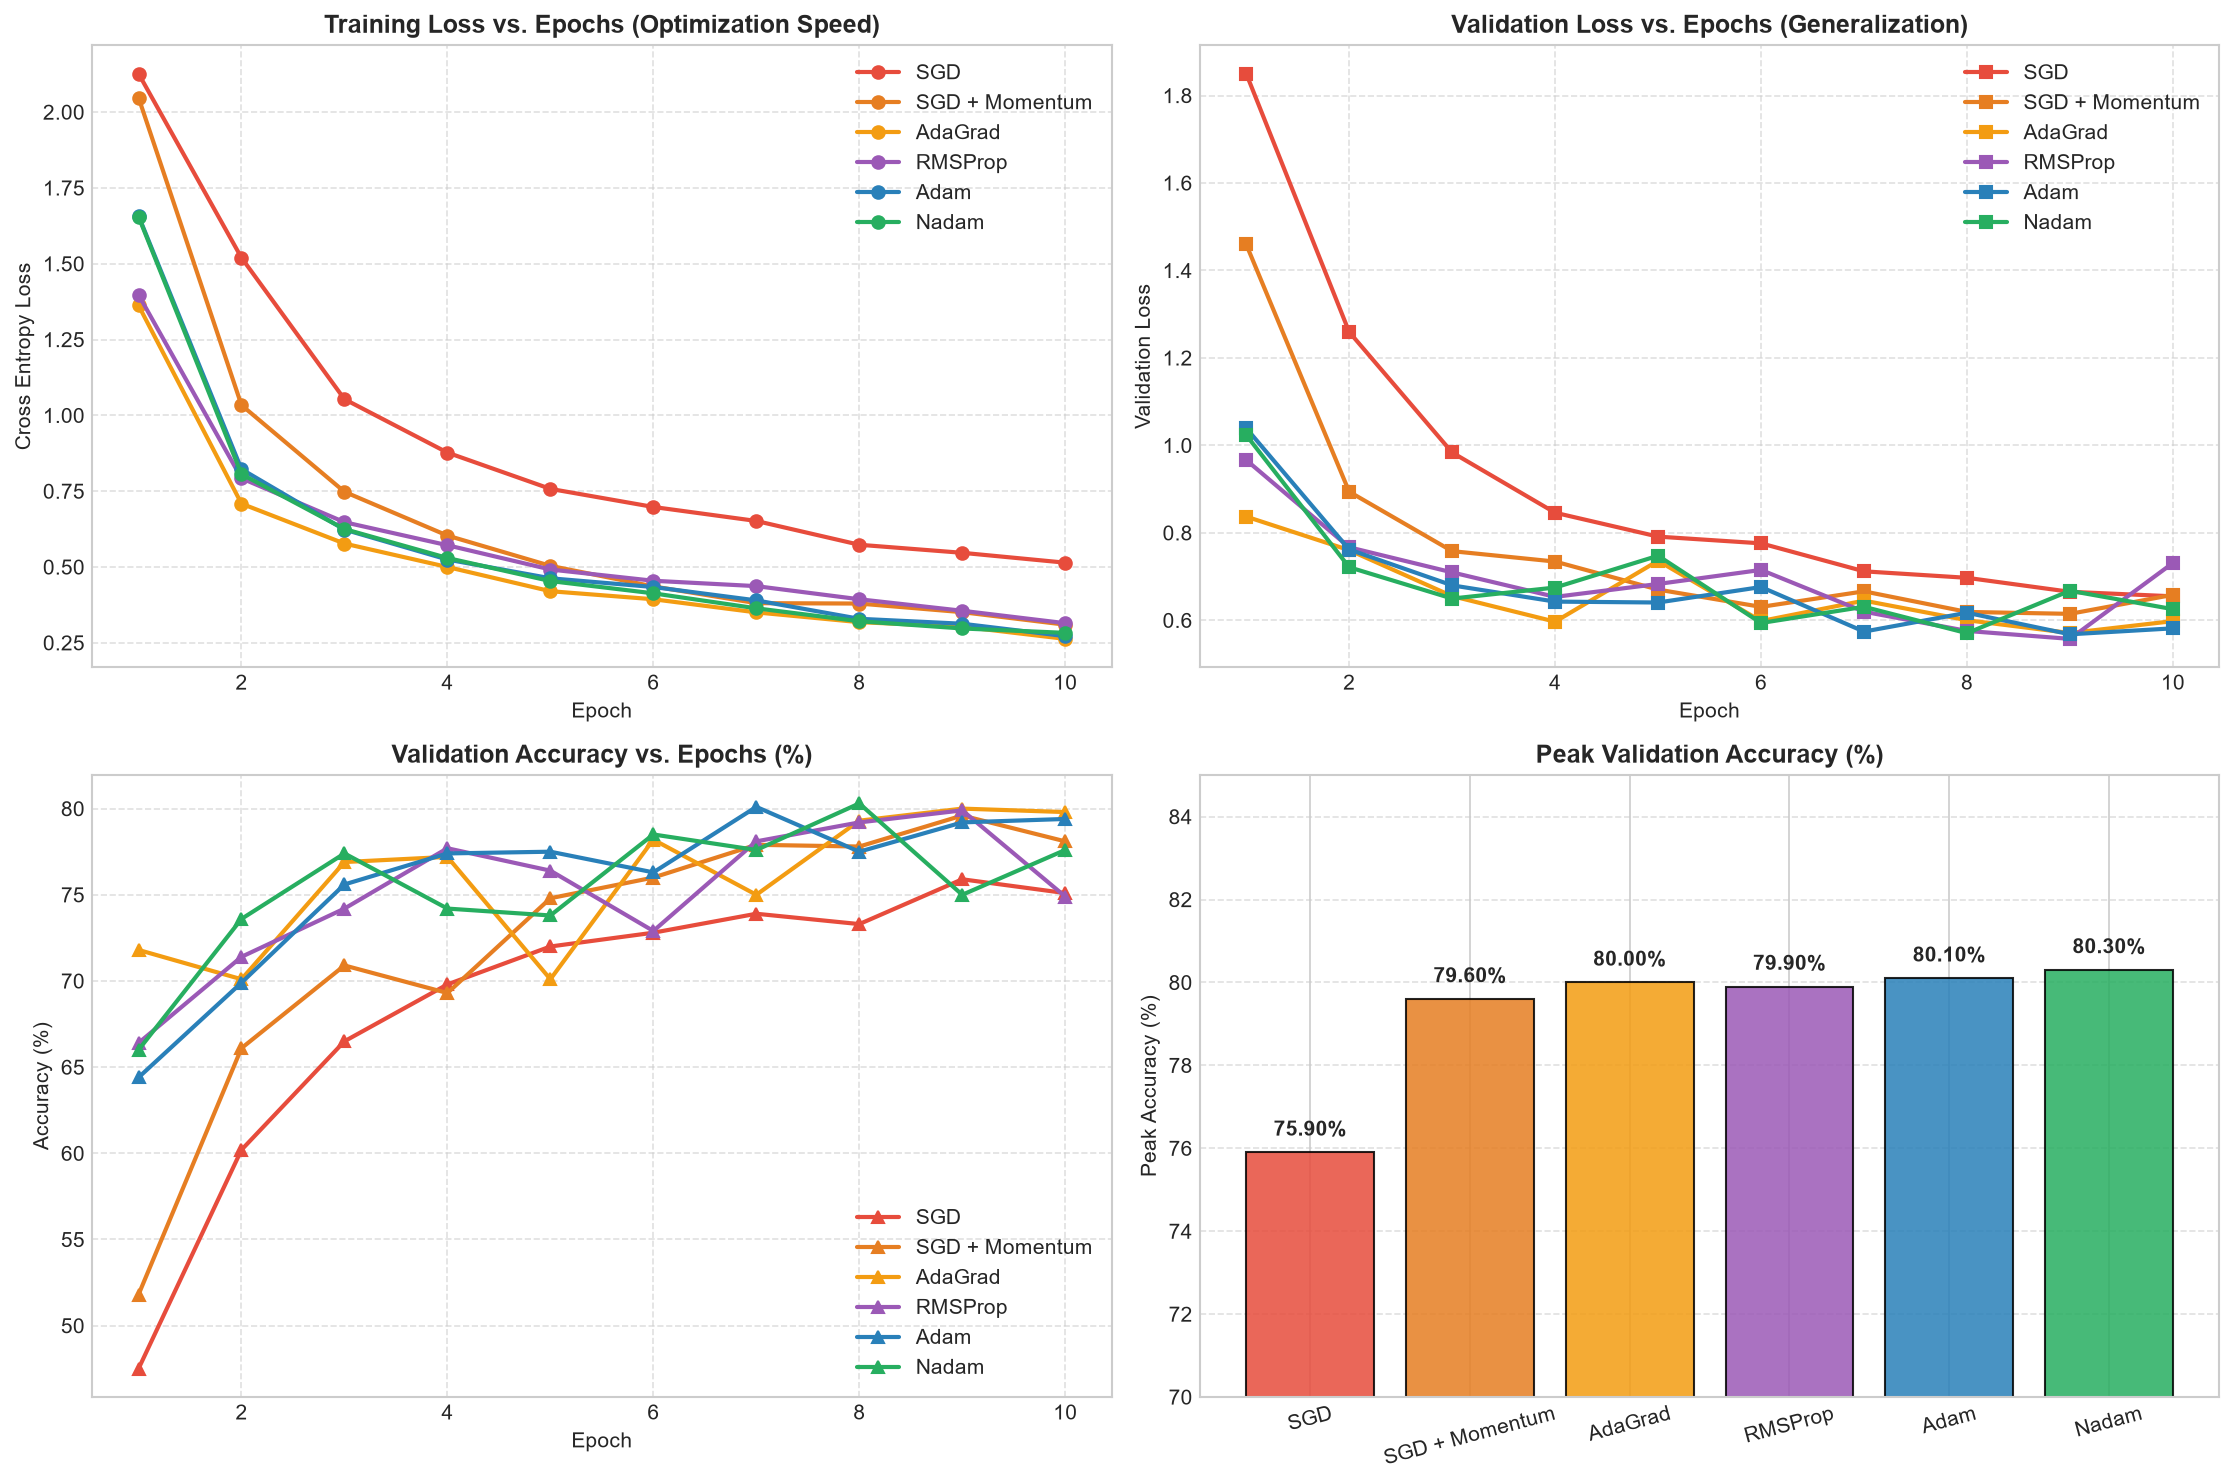

In [6]:
# -------------------------------------------------------------
# STEP 6: Visualization Dashboard (4-Panel Curves)
# -------------------------------------------------------------
epochs_axis = list(range(1, TOTAL_EPOCHS + 1))
color_map = {
    "SGD": "#e74c3c",
    "SGD + Momentum": "#e67e22",
    "AdaGrad": "#f39c12",
    "RMSProp": "#9b59b6",
    "Adam": "#2980b9",
    "Nadam": "#27ae60"
}

plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
fig, axs = plt.subplots(2, 2, figsize=(15, 10))

# 1. Training Loss
for name, hist in all_histories.items():
    axs[0, 0].plot(epochs_axis, hist["train_loss"], label=name, color=color_map[name], marker='o', linewidth=2)
axs[0, 0].set_title("Training Loss vs. Epochs (Optimization Speed)", fontsize=12, fontweight='bold')
axs[0, 0].set_xlabel("Epoch")
axs[0, 0].set_ylabel("Cross Entropy Loss")
axs[0, 0].legend()
axs[0, 0].grid(True, linestyle="--", alpha=0.6)

# 2. Validation Loss
for name, hist in all_histories.items():
    axs[0, 1].plot(epochs_axis, hist["val_loss"], label=name, color=color_map[name], marker='s', linewidth=2)
axs[0, 1].set_title("Validation Loss vs. Epochs (Generalization)", fontsize=12, fontweight='bold')
axs[0, 1].set_xlabel("Epoch")
axs[0, 1].set_ylabel("Validation Loss")
axs[0, 1].legend()
axs[0, 1].grid(True, linestyle="--", alpha=0.6)

# 3. Validation Accuracy
for name, hist in all_histories.items():
    axs[1, 0].plot(epochs_axis, hist["val_acc"], label=name, color=color_map[name], marker='^', linewidth=2)
axs[1, 0].set_title("Validation Accuracy vs. Epochs (%)", fontsize=12, fontweight='bold')
axs[1, 0].set_xlabel("Epoch")
axs[1, 0].set_ylabel("Accuracy (%)")
axs[1, 0].legend()
axs[1, 0].grid(True, linestyle="--", alpha=0.6)

# 4. Peak Accuracy Bar Chart
opts = df_summary["Optimizer"].tolist()
peaks = df_summary["Peak Val Acc (%)"].tolist()
bars = axs[1, 1].bar(opts, peaks, color=[color_map[o] for o in opts], alpha=0.85, edgecolor='black')
axs[1, 1].set_ylim(70, 85)
axs[1, 1].set_title("Peak Validation Accuracy (%)", fontsize=12, fontweight='bold')
axs[1, 1].set_ylabel("Peak Accuracy (%)")
for bar in bars:
    y = bar.get_height()
    axs[1, 1].text(bar.get_x() + bar.get_width()/2.0, y + 0.3, f"{y:.2f}%", ha='center', va='bottom', fontweight='bold')
axs[1, 1].tick_params(axis='x', rotation=15)
axs[1, 1].grid(True, axis='y', linestyle="--", alpha=0.6)

plt.tight_layout()
plt.show()


[+] Testing Learning Rate Sensitivity across eta in [0.1, 0.01, 0.001, 0.0001]...
  > SGD             @ lr=0.1     | 3-Epoch Val Acc = 58.80%
  > SGD             @ lr=0.01    | 3-Epoch Val Acc = 40.60%
  > SGD             @ lr=0.001   | 3-Epoch Val Acc = 12.20%
  > SGD             @ lr=0.0001  | 3-Epoch Val Acc = 7.00%
  > SGD + Momentum  @ lr=0.1     | 3-Epoch Val Acc = 70.90%
  > SGD + Momentum  @ lr=0.01    | 3-Epoch Val Acc = 69.40%
  > SGD + Momentum  @ lr=0.001   | 3-Epoch Val Acc = 37.90%
  > SGD + Momentum  @ lr=0.0001  | 3-Epoch Val Acc = 10.80%
  > AdaGrad         @ lr=0.1     | 3-Epoch Val Acc = 70.70%
  > AdaGrad         @ lr=0.01    | 3-Epoch Val Acc = 70.90%
  > AdaGrad         @ lr=0.001   | 3-Epoch Val Acc = 70.60%
  > AdaGrad         @ lr=0.0001  | 3-Epoch Val Acc = 37.50%
  > Adam            @ lr=0.1     | 3-Epoch Val Acc = 32.70%
  > Adam            @ lr=0.01    | 3-Epoch Val Acc = 74.60%
  > Adam            @ lr=0.001   | 3-Epoch Val Acc = 74.50%
  > Adam           

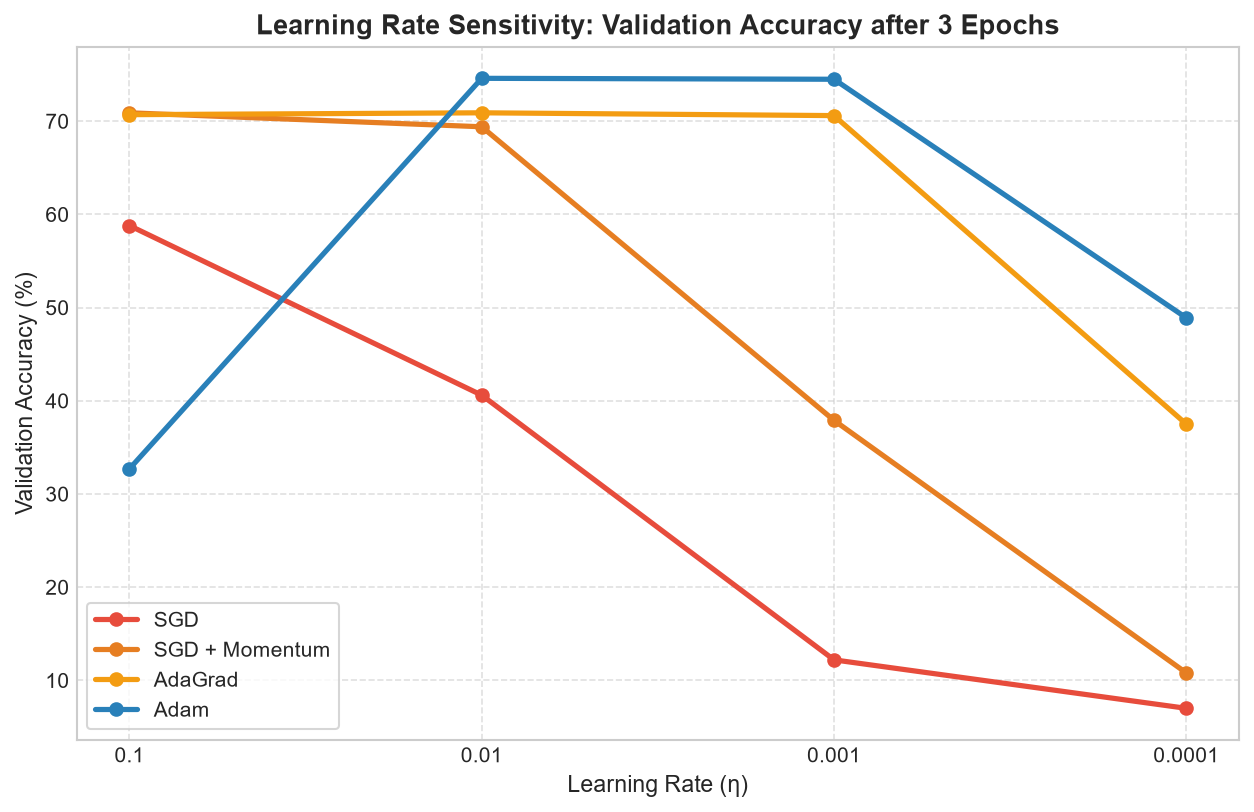

In [7]:
# -------------------------------------------------------------
# STEP 7: Learning Rate Sensitivity Sweep (4 Orders of Magnitude)
# -------------------------------------------------------------
learning_rates = [0.1, 0.01, 0.001, 0.0001]
tested_optimizers = ["SGD", "SGD + Momentum", "AdaGrad", "Adam"]
sensitivity_scores = {opt: [] for opt in tested_optimizers}

def build_sens_opt(opt_name, model_inst, lr_val):
    if opt_name == "SGD":
        return optim.SGD(model_inst.parameters(), lr=lr_val)
    elif opt_name == "SGD + Momentum":
        return optim.SGD(model_inst.parameters(), lr=lr_val, momentum=0.9)
    elif opt_name == "AdaGrad":
        return optim.Adagrad(model_inst.parameters(), lr=lr_val)
    elif opt_name == "Adam":
        return optim.Adam(model_inst.parameters(), lr=lr_val)

print("[+] Testing Learning Rate Sensitivity across eta in [0.1, 0.01, 0.001, 0.0001]...")
for opt_name in tested_optimizers:
    for lr in learning_rates:
        set_seed(42)
        m = BenchmarkMLP().to(device)
        m.load_state_dict(copy.deepcopy(initial_weights))
        opt = build_sens_opt(opt_name, m, lr)
        
        m.train()
        for epoch in range(3):
            for x, y in train_loader:
                x, y = x.to(device), y.to(device)
                opt.zero_grad()
                out = m(x)
                loss = criterion(out, y)
                loss.backward()
                opt.step()
                
        _, acc = evaluate_model(m, val_loader)
        sensitivity_scores[opt_name].append(acc)
        print(f"  > {opt_name:15s} @ lr={lr:<7} | 3-Epoch Val Acc = {acc:.2f}%")

# Plot sensitivity curve
plt.figure(figsize=(10, 6))
for opt_name in tested_optimizers:
    plt.plot([str(lr) for lr in learning_rates], sensitivity_scores[opt_name],
             marker='o', linewidth=2.5, label=opt_name, color=color_map[opt_name])

plt.title("Learning Rate Sensitivity: Validation Accuracy after 3 Epochs", fontsize=13, fontweight='bold')
plt.xlabel("Learning Rate (\u03b7)", fontsize=11)
plt.ylabel("Validation Accuracy (%)", fontsize=11)
plt.legend(frameon=True)
plt.grid(True, linestyle="--", alpha=0.6)
plt.show()


## 8. The Generalization Mystery: Adam vs. SGD + Momentum

### Key Question:
> *"Why does Adam converge faster during training, yet SGD with Momentum often produces better generalization on unseen test data?"*

### The Answer: Flat vs. Sharp Minima
1. **Optimization Speed $\\neq$ Model Quality:** Fast drop in training loss does not guarantee superior performance on unseen distributions.
2. **Sharp Minima (Adam):** Because Adam adaptively scales coordinates, it easily slips into narrow, sharp crevices. In a sharp minimum, a tiny shift between training and test sets causes an exponential error surge.
3. **Flat Minima (SGD + Momentum):** Because SGD+Momentum uses uniform step sizes and kinetic velocity, it bounces out of sharp crevices and settles into broad, flat valleys. In a flat minimum, small distributional shifts produce virtually no change in test accuracy.

```
 Loss
  ▲
  │       Sharp Minimum (Adam)           Flat Minimum (SGD + Momentum)
  │       High Test Error Shift             Low Test Error Shift
  │
  │           \     /                              \             /
  │            \   /                                \___________/
  │             \_/
  │          Training: Low Loss               Training: Low Loss
  │          Testing:  HIGH ERROR             Testing:  LOW ERROR
  └───────────────────────────────────────────────────────────────────► Weights (θ)
```


## 9. Viva Defense Quick Reference (10-Second Answers)

* **Q1: What optimizer for sparse gradients?**  
  *Answer:* **AdaGrad or Adam**, because their adaptive second moment divides by historical squared gradients, automatically amplifying updates for rare features.
* **Q2: What optimizer for noisy gradients?**  
  *Answer:* **SGD with Momentum or Adam**, because the first-moment running average acts as a low-pass filter, dampening noisy oscillations.
* **Q3: How to escape saddle points?**  
  *Answer:* **Adam or SGD + Momentum**, because accumulated velocity carries parameters across flat zero-gradient plateaus.
* **Q4: Why divide by $(1-\beta^t)$ in Adam?**  
  *Answer:* Because moment vectors are initialized at zero; dividing by $(1-\beta^t)$ cancels out the initialization bias during early iterations.
